NOTE: This is a condensed version of a larger study project, most text analysis parts of the codes output is removed. The code is largely unchanged. In a Jupyter Notebook format for easier text between code and so that it is easier to read.

Goal: extract several features from images of different types of leaves for classification purposes, determine the best hyperparameters for 3 different machine learning classification models and examine which model performes the best in classifying the leave images.

Data: consists of images of leaves from 3 different types of plants: Basil, Chinar and Lemon. There are  60 images of Basil leaves, and 62 images of Chinar and Lemon leaves. Image source: Kaggle.

### Importing the libraries

In [ ]:
import statistics
import pandas as pandas
import numpy as numpy
import sklearn as sklearn
import skimage as skimage
import matplotlib as matplotlib
import scipy as scipy
import seaborn as seaborn

### Data preparation

In [ ]:
# Reading the images
basil_images=skimage.io.imread_collection('Basil/*.JPG')
chinar_images=skimage.io.imread_collection('Chinar/*.JPG')
lemon_images=skimage.io.imread_collection('Lemon/*.JPG')

### Feature Extraction

In [ ]:
# Calculating the means and variances of the RGB channels
def rgb_mean_variance(data):
  """Returns the means and variances of the RGB channels"""
  means=[[],[],[]]
  variances=[[],[],[]]
  for image in data:
    for i in range(0,3):
      means[i].append(numpy.mean(image[:,:,i]))
      variances[i].append(numpy.var(image[:,:,i]))
  return means, variances

basil_means, basil_variances=rgb_mean_variance(basil_images)
print("Basil images RGB channel average means and variances:")
print(f"Means: R:{round(statistics.mean(basil_means[0]),3)} G:{round(statistics.mean(basil_means[1]),3)} B:{round(statistics.mean(basil_means[2]),3)}")
print(f"Variances: R:{round(statistics.mean(basil_variances[0]),3)} G:{round(statistics.mean(basil_variances[1]),3)} B:{round(statistics.mean(basil_variances[2]),3)}")
print("")

chinar_means, chinar_variances=rgb_mean_variance(chinar_images)
print("Chinar images RGB channel averages mean and variances:")
print(f"Means: R:{round(statistics.mean(chinar_means[0]),3)} G:{round(statistics.mean(chinar_means[1]),3)} B:{round(statistics.mean(chinar_means[2]),3)}")
print(f"Variances: R:{round(statistics.mean(chinar_variances[0]),3)} G:{round(statistics.mean(chinar_variances[1]),3)} B:{round(statistics.mean(chinar_variances[2]),3)}")
print("")

lemon_means, lemon_variances=rgb_mean_variance(lemon_images)
print("Lemon images RGB channel average means and variances:")
print(f"Means: R:{round(statistics.mean(lemon_means[0]),3)} G:{round(statistics.mean(lemon_means[1]),3)} B:{round(statistics.mean(lemon_means[2]),3)}")
print(f"Variances: R:{round(statistics.mean(lemon_variances[0]),3)} G:{round(statistics.mean(lemon_variances[1]),3)} B:{round(statistics.mean(lemon_variances[2]),3)}")

Basil images RGB channel average means and variances:
Means: R:42.02 G:45.718 B:39.097
Variances: R:336.344 G:751.921 B:142.448

Chinar images RGB channel averages mean and variances:
Means: R:56.439 G:66.211 B:59.391
Variances: R:448.287 G:1013.707 B:347.298

Lemon images RGB channel average means and variances:
Means: R:49.595 G:54.468 B:46.086
Variances: R:351.429 G:744.811 B:160.632


### Second order texture measures (grayscale conversion and quantization ; GLMC correlation)

In [ ]:
# Converting to grayscale
def grayscale(images):
  """Convert an RGB image collection to grayscale"""
  gray_images=[]
  for image in images:
    arr=skimage.color.rgb2gray(image)
    arr*=255
    arr=numpy.round(arr).astype(numpy.uint8)
    gray_images.append(arr)
  return gray_images

basil_data_gray=grayscale(basil_images)
chinar_data_gray=grayscale(chinar_images)
lemon_data_gray=grayscale(lemon_images)

In [ ]:
# Reducing grayscale quantization
def gray_quant_reduce(gray_images, quant_level):
  """"Reduce the quantization of grayscale images"""
  gray_images_quant=[]
  for image in gray_images:
    image_quantized=(numpy.round(image*(quant_level-1))/(quant_level-1)).astype(numpy.uint8)
    gray_images_quant.append(image_quantized)
  return gray_images_quant

quant_level=8
basil_data_gray_quant=gray_quant_reduce(basil_data_gray, quant_level)
chinar_data_gray_quant=gray_quant_reduce(chinar_data_gray, quant_level)
lemon_data_gray_quant=gray_quant_reduce(lemon_data_gray, quant_level)

In [ ]:
# Calculating the gray level co-occurrence matrixes (distances 1 and 2, directions horizontal and vertical)
# (matrix 1 = distance 1, horizontal ; matrix 2 = distance 1, vertical ; matrix 3 = distance 2, horizontal ; matrix 4 = distance 1, vertical)
distances=[1, 2]
angles=[[0, numpy.pi],[numpy.pi/2, 3*numpy.pi/2]]

def get_glcm_correlations(images, distances, angles):
  """Calculates glmc correlations"""
  graycomatrices=[]
  for image in images:
    matrix1=skimage.feature.graycomatrix(image, [distances[0]], angles[0])
    matrix2=skimage.feature.graycomatrix(image, [distances[0]], angles[1])
    matrix3=skimage.feature.graycomatrix(image, [distances[1]], angles[0])
    matrix4=skimage.feature.graycomatrix(image, [distances[1]], angles[1])
    graycomatrices.append([matrix1, matrix2, matrix3, matrix4])
  correlations=[]
  for matrices in graycomatrices:
    cors=[]
    for matrix in matrices:
      cors.append(skimage.feature.graycoprops(matrix,'correlation'))
    correlations.append(cors)
  return correlations

In [ ]:
# Basil correlation
basil_correlations=get_glcm_correlations(basil_data_gray_quant, distances, angles)
chinar_correlations=get_glcm_correlations(chinar_data_gray_quant, distances, angles)
lemon_correlations=get_glcm_correlations(lemon_data_gray_quant, distances, angles)

In [ ]:
# Printing out the correlation features:
print(f"Basil mean correlation: {round(numpy.mean(basil_correlations),3)}")
print(f"Chinar mean correlation: {round(numpy.mean(chinar_correlations),3)}")
print(f"Lemon mean correlation: {round(numpy.mean(lemon_correlations),3)}")

Basil mean correlation: 0.686
Chinar mean correlation: 0.668
Lemon mean correlation: 0.773


### Additional image-based features (template matching scores)

In [ ]:
# Finding the representative images
basil_represenative_image=basil_data_gray_quant[numpy.argmin([scipy.spatial.distance.euclidean(numpy.array(correlation).ravel(), numpy.mean(basil_correlations, axis=0).ravel()) for correlation in basil_correlations])]
chinar_represenative_image=chinar_data_gray_quant[numpy.argmin([scipy.spatial.distance.euclidean(numpy.array(correlation).ravel(), numpy.mean(chinar_correlations, axis=0).ravel()) for correlation in chinar_correlations])]
lemon_represenative_image=lemon_data_gray_quant[numpy.argmin([scipy.spatial.distance.euclidean(numpy.array(correlation).ravel(), numpy.mean(lemon_correlations, axis=0).ravel()) for correlation in lemon_correlations])]

In [ ]:
# Calculating the template matching scores and the maxium response
basil_template_match_to_basil=[(skimage.feature.match_template(image, basil_represenative_image)).max() for image in basil_data_gray_quant]
basil_template_match_to_chinar=[(skimage.feature.match_template(image, chinar_represenative_image)).max() for image in basil_data_gray_quant]
basil_template_match_to_lemon=[(skimage.feature.match_template(image, lemon_represenative_image)).max() for image in basil_data_gray_quant]

chinar_template_match_to_basil=[(skimage.feature.match_template(image, basil_represenative_image)).max() for image in chinar_data_gray_quant]
chinar_template_match_to_chinar=[(skimage.feature.match_template(image, chinar_represenative_image)).max() for image in chinar_data_gray_quant]
chinar_template_match_to_lemon=[(skimage.feature.match_template(image, lemon_represenative_image)).max() for image in chinar_data_gray_quant]

lemon_template_match_to_basil=[(skimage.feature.match_template(image, basil_represenative_image)).max() for image in lemon_data_gray_quant]
lemon_template_match_to_chinar=[(skimage.feature.match_template(image, chinar_represenative_image)).max() for image in lemon_data_gray_quant]
lemon_template_match_to_lemon=[(skimage.feature.match_template(image, lemon_represenative_image)).max() for image in lemon_data_gray_quant]

### Data combining and normalisation

In [ ]:
# Taking all the data together, normalising using z-score standardization and constructing a DataFrame containing all the images
columns=['red mean','green mean','blue mean','red variance','green variance','blue variance','correlation 1', 'correlation 2', 'correlation 3', 'correlation 4', 'basil template match', 'chinar template match', 'lemon template match']

def construct_data_array(columns, means, variances, correlations, template_match_to_basil, template_match_to_chinar, template_match_to_lemon):
  data=numpy.array([means[0],means[1],means[2],variances[0],variances[1],variances[2],[numpy.mean(correlation[0]) for correlation in correlations], [numpy.mean(correlation[1]) for correlation in correlations], [numpy.mean(correlation[2]) for correlation in correlations], [numpy.mean(correlation) for correlation in correlations], [numpy.mean(matching) for matching in template_match_to_basil], [numpy.mean(matching) for matching in template_match_to_chinar], [numpy.mean(matching) for matching in template_match_to_lemon]])
  data=data.T
  data=sklearn.preprocessing.StandardScaler().fit_transform(data)
  return pandas.DataFrame(data,columns=columns)

basil_images=construct_data_array(columns, basil_means, basil_variances, basil_correlations, basil_template_match_to_basil, basil_template_match_to_chinar, basil_template_match_to_lemon)
basil_images['class']='Basil'

chinar_images=construct_data_array(columns, chinar_means, chinar_variances, chinar_correlations, chinar_template_match_to_basil, chinar_template_match_to_chinar, chinar_template_match_to_lemon)
chinar_images['class']='Chinar'

lemon_images=construct_data_array(columns, lemon_means, lemon_variances, lemon_correlations, lemon_template_match_to_basil, lemon_template_match_to_chinar, lemon_template_match_to_lemon)
lemon_images['class']='Lemon'

In [ ]:
classes=[basil_images, chinar_images, lemon_images]
all_images=pandas.concat(classes, ignore_index=True)

### Feature Relationships (pairplot of features ; Principal Component Analysis)


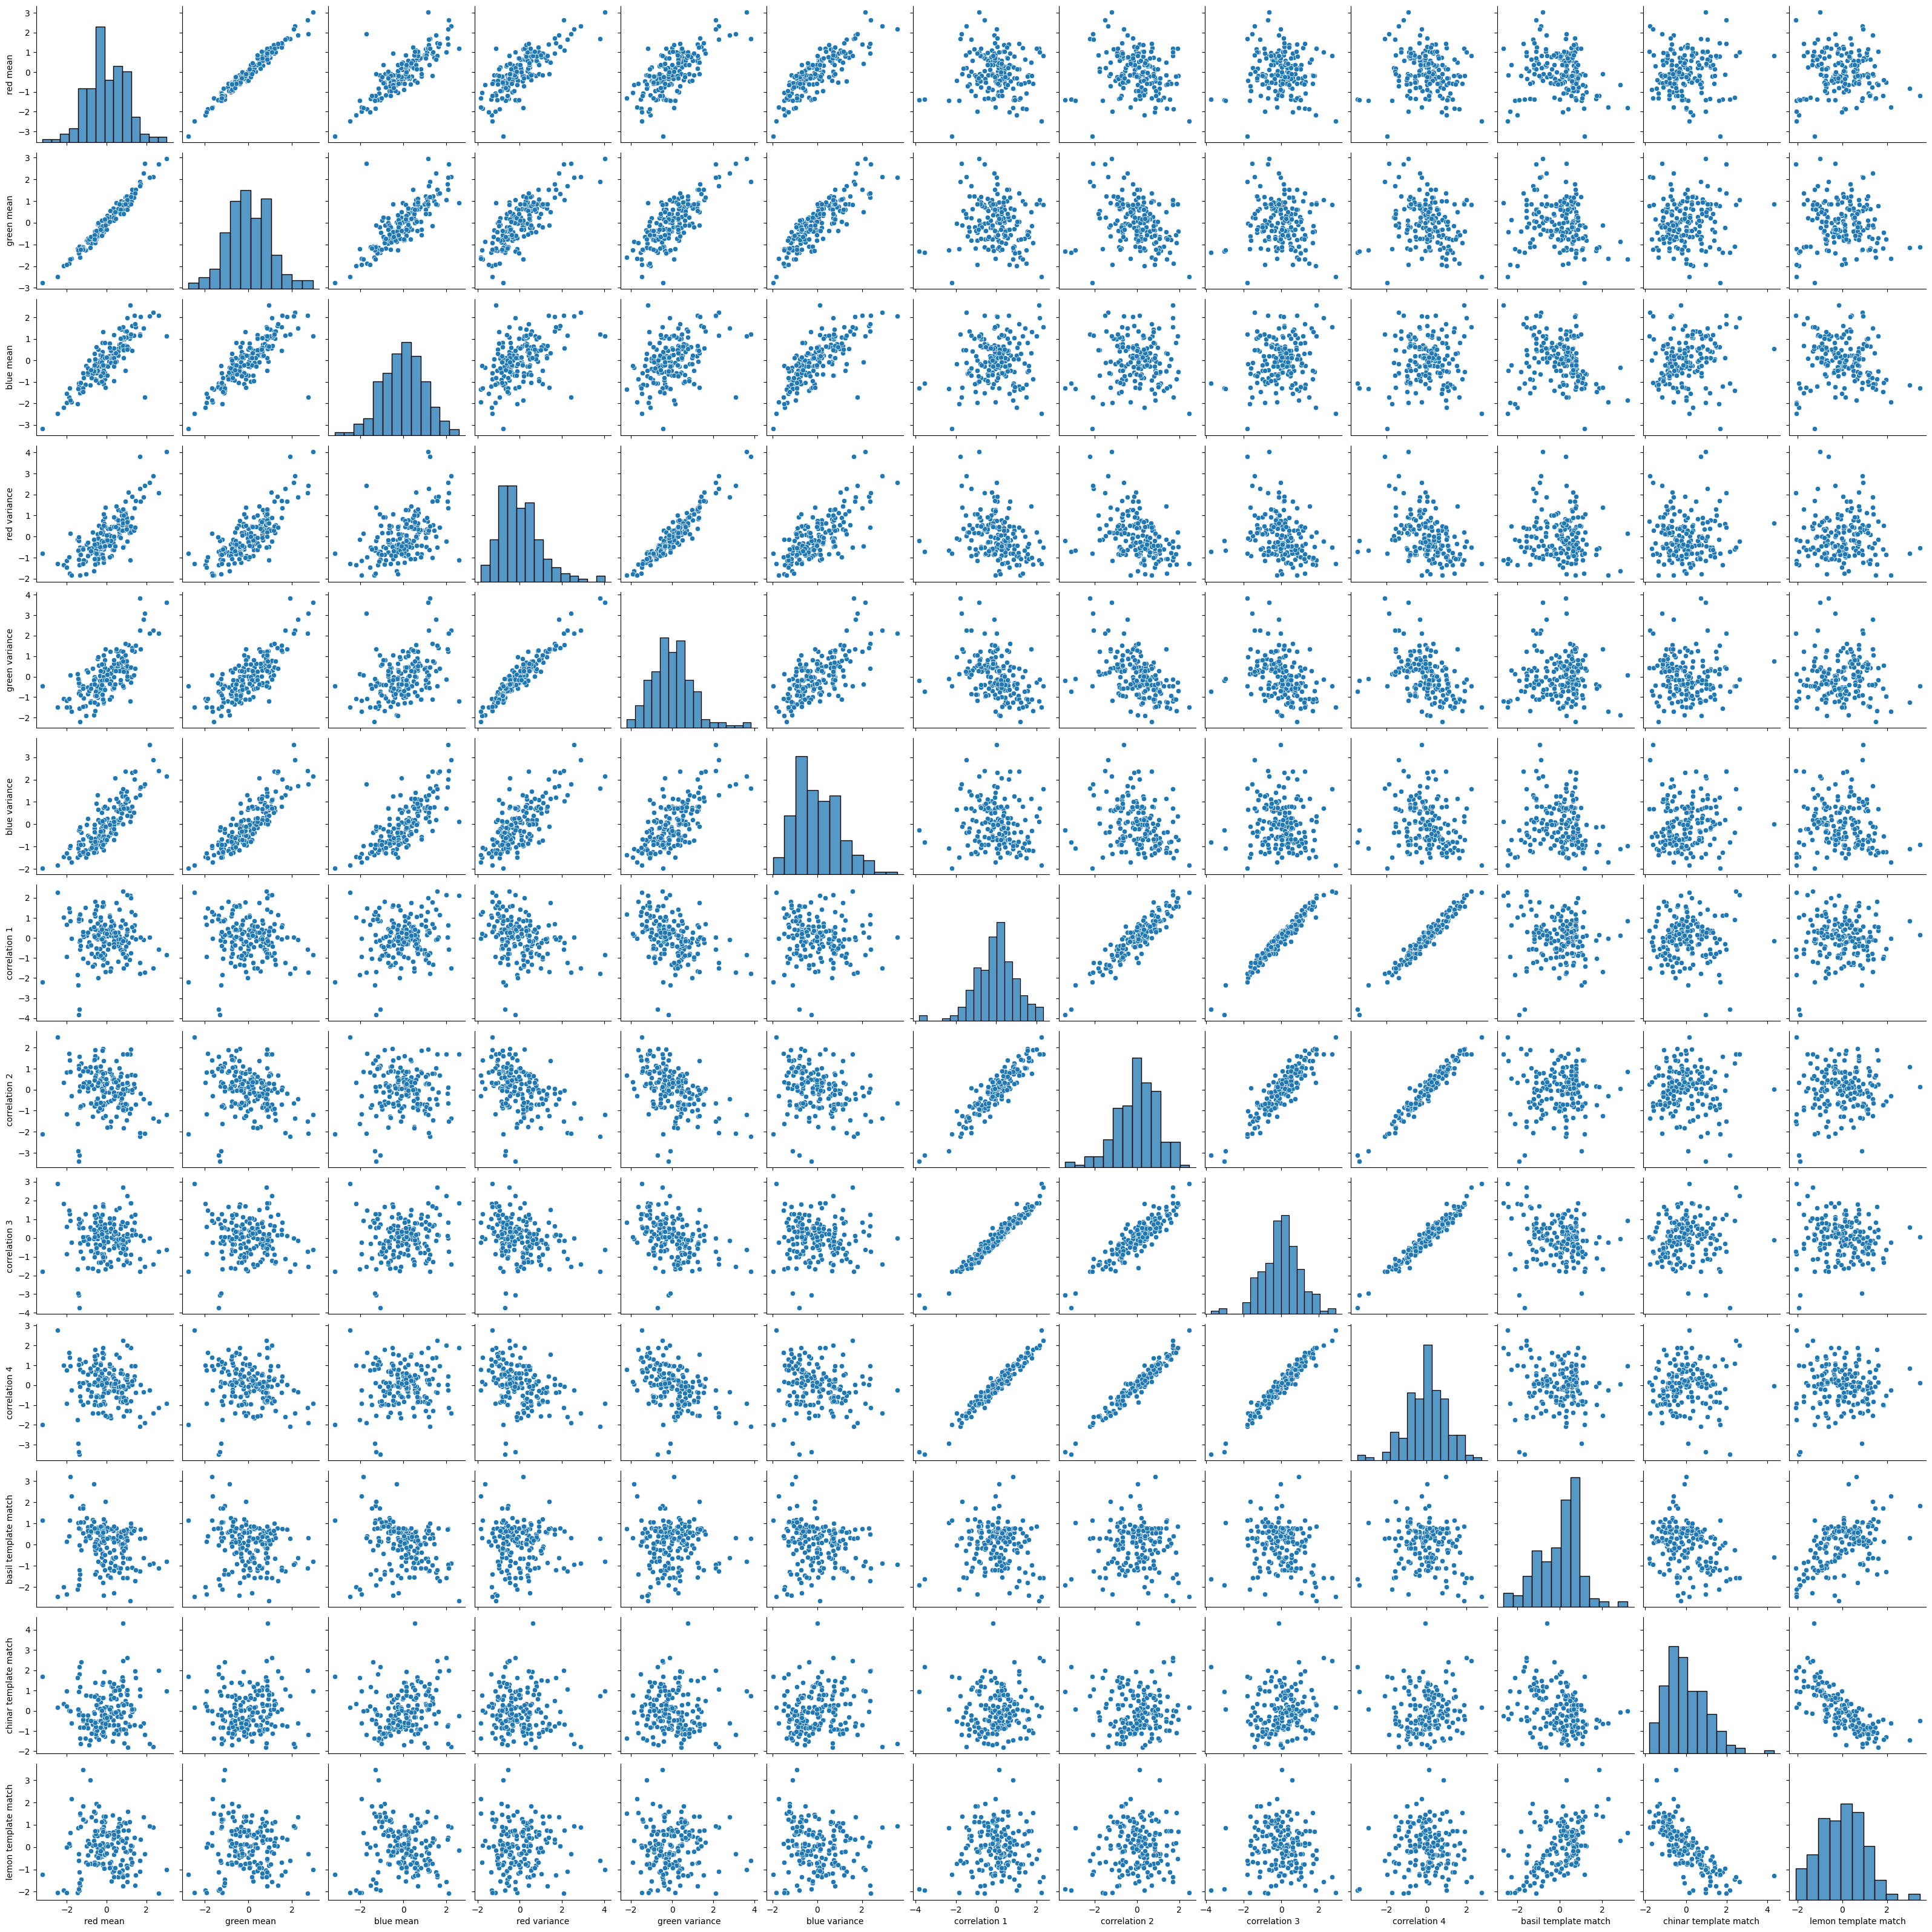

In [ ]:
seaborn.pairplot(all_images)
matplotlib.pyplot.show()

### Histograms

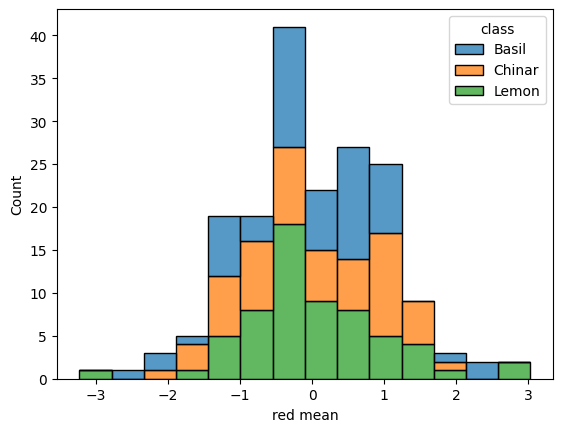

In [ ]:
seaborn.histplot(all_images, x="red mean", hue="class", multiple="stack")
matplotlib.pyplot.show()

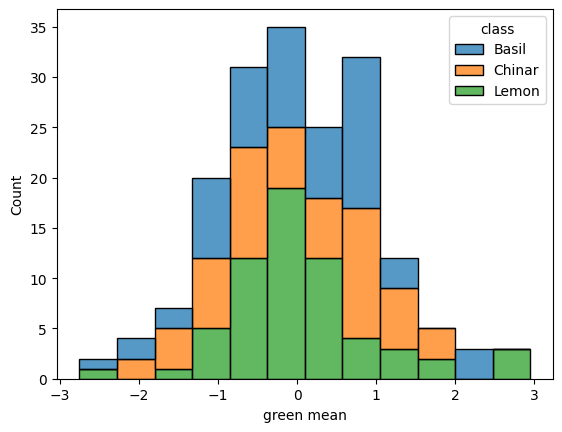

In [ ]:
seaborn.histplot(all_images, x="green mean", hue="class", multiple="stack")
matplotlib.pyplot.show()

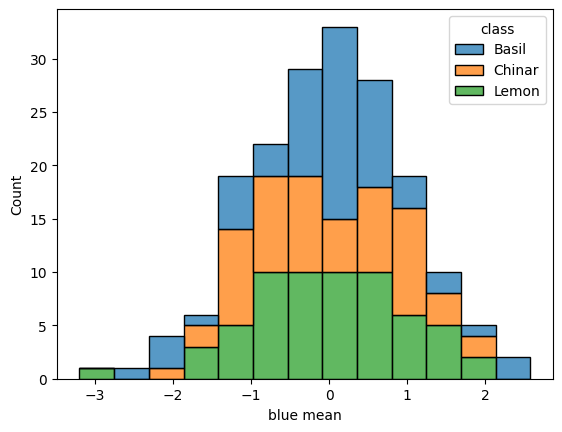

In [ ]:
seaborn.histplot(all_images, x="blue mean", hue="class", multiple="stack")
matplotlib.pyplot.show()

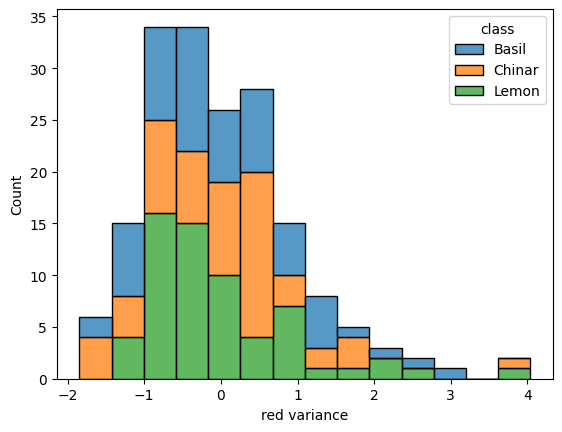

In [ ]:
seaborn.histplot(all_images, x="red variance", hue="class", multiple="stack")
matplotlib.pyplot.show()

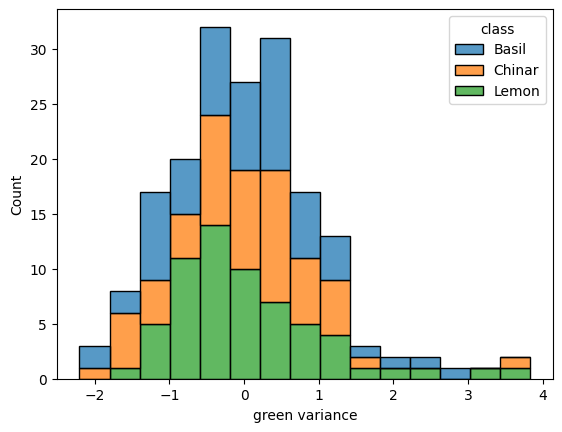

In [ ]:
seaborn.histplot(all_images, x="green variance", hue="class", multiple="stack")
matplotlib.pyplot.show()

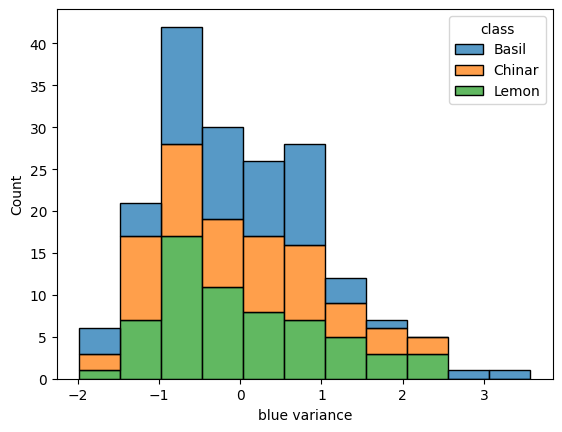

In [ ]:
seaborn.histplot(all_images, x="blue variance", hue="class", multiple="stack")
matplotlib.pyplot.show()

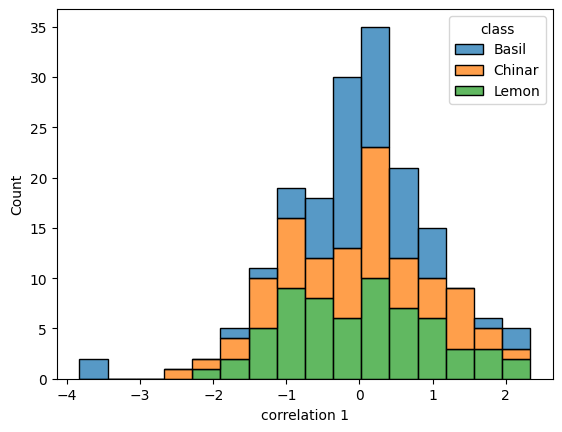

In [ ]:
seaborn.histplot(all_images, x="correlation 1", hue="class", multiple="stack")
matplotlib.pyplot.show()

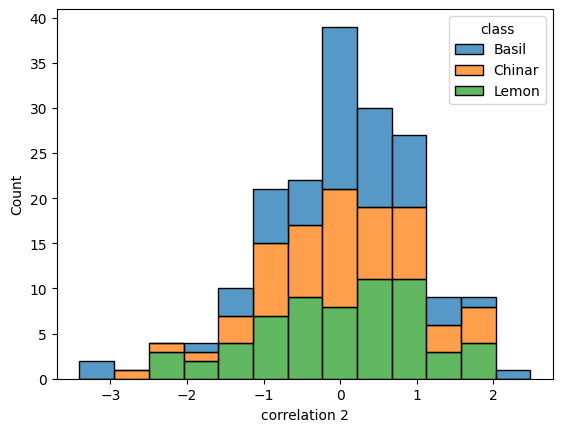

In [ ]:
seaborn.histplot(all_images, x="correlation 2", hue="class", multiple="stack")
matplotlib.pyplot.show()

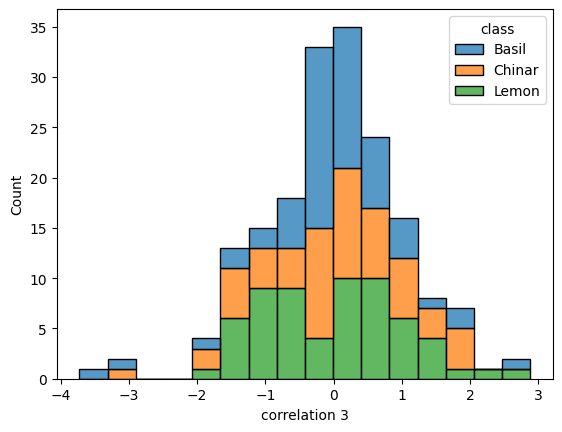

In [ ]:
seaborn.histplot(all_images, x="correlation 3", hue="class", multiple="stack")
matplotlib.pyplot.show()

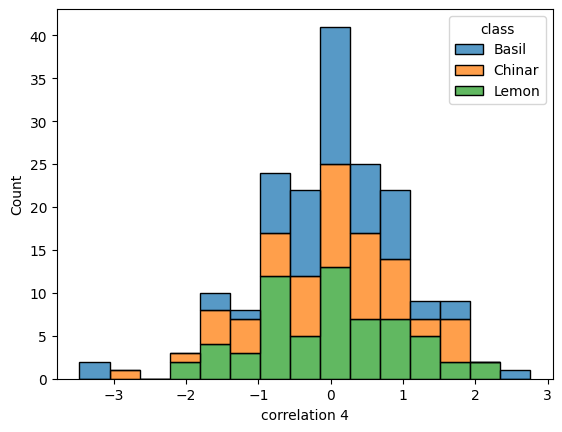

In [ ]:
seaborn.histplot(all_images, x="correlation 4", hue="class", multiple="stack")
matplotlib.pyplot.show()

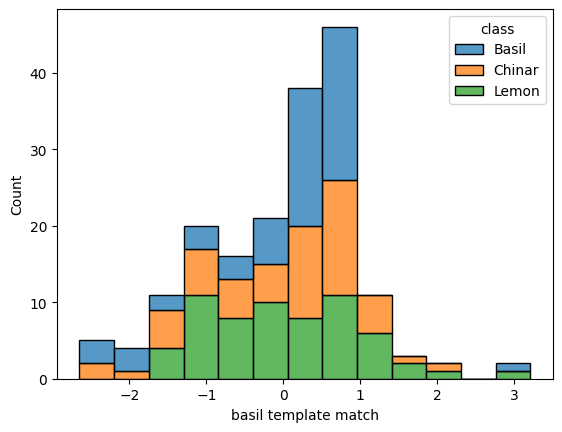

In [ ]:
seaborn.histplot(all_images, x="basil template match", hue="class", multiple="stack")
matplotlib.pyplot.show()

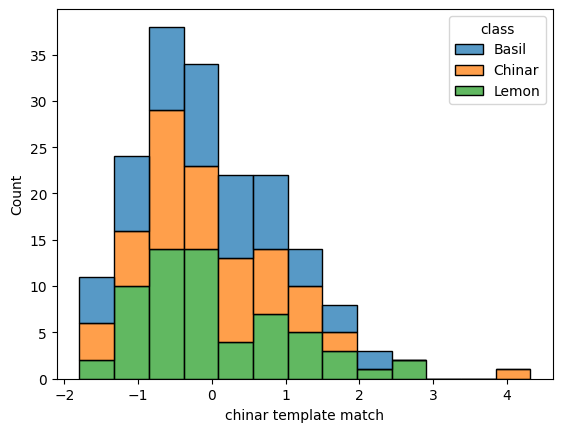

In [ ]:
seaborn.histplot(all_images, x="chinar template match", hue="class", multiple="stack")
matplotlib.pyplot.show()

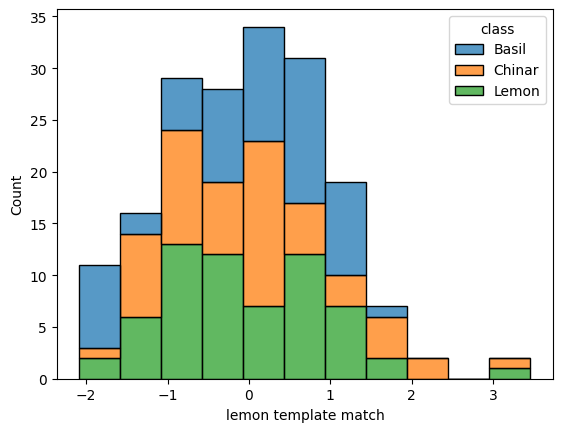

In [ ]:
seaborn.histplot(all_images, x="lemon template match", hue="class", multiple="stack")
matplotlib.pyplot.show()

### Principal Component Analysis

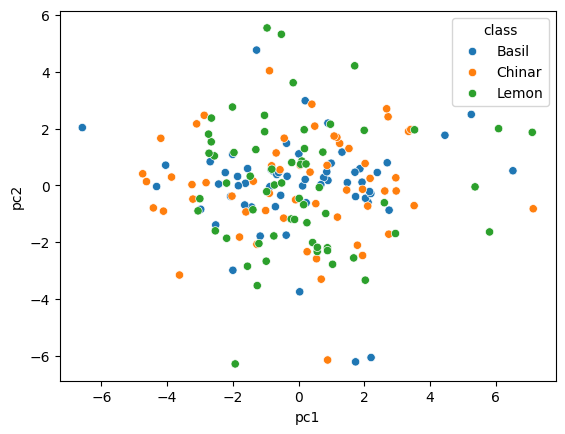

In [ ]:
# PCA
data_no_class=all_images.drop(['class'], axis=1)
data_classes=all_images['class']
pca=sklearn.decomposition.PCA(n_components=2)
fitted=pandas.DataFrame(pca.fit_transform(data_no_class), columns=['pc1', 'pc2'])
fitted=pandas.concat([fitted, data_classes], axis=1)
seaborn.scatterplot(data=fitted, x="pc1", y="pc2", hue="class")
matplotlib.pyplot.show()

In [ ]:
data_plants=all_images['class']
data_classes=pandas.Categorical(data_plants)
data_classes=pandas.DataFrame(data_classes.rename_categories({'Basil':0, 'Chinar':1, 'Lemon':2}))

### Ridge Classifier

In [ ]:
# Ridge Classifier
def ridge_classifier(n_splits, data_no_class, data_classes, alphas):
  """Calculates best hyperparameters and accuracies of Ridge Classifier using GridSeachCV and stratified K-Fold cross-validation"""
  ridge_accuracies=[]
  skf=sklearn.model_selection.StratifiedKFold(n_splits=n_splits)
  for train_index, test_index in skf.split(data_no_class, data_classes):
    X_test, y_test = data_no_class.iloc[test_index], data_classes.iloc[test_index]
    X_train, y_train = data_no_class.iloc[train_index], data_classes.iloc[train_index]
    rc_gscv=sklearn.model_selection.GridSearchCV(sklearn.linear_model.RidgeClassifier(), {'alpha':alphas})
    rc_gscv.fit(X_train, y_train.to_numpy().ravel())
    best_params=rc_gscv.best_params_
    ridge_accuracies.append(([best_params['alpha']], sklearn.metrics.accuracy_score(y_test,sklearn.linear_model.RidgeClassifier(alpha=best_params['alpha']).fit(X_train, y_train.to_numpy().ravel()).predict(X_test))))
  return ridge_accuracies

In [ ]:
alphas=[0.001, 0.01, 0.1, 1.0]
ridge_accuracies=ridge_classifier(5, data_no_class, data_classes, alphas)

In [ ]:
print("Ridge Classifier")
for i in ridge_accuracies:
  print(f"Accuracy: {round(i[1],3)}, hyperparameters:{i[0]}")

Ridge Classifier
Accuracy: 0.139, hyperparameters:[0.001]
Accuracy: 0.083, hyperparameters:[0.001]
Accuracy: 0.083, hyperparameters:[1.0]
Accuracy: 0.083, hyperparameters:[0.001]
Accuracy: 0.2, hyperparameters:[1.0]


### Random Forest

In [ ]:
# Random Forest
def random_forest_classifier(n_splits, data_no_class, data_classes, n_estimators, max_features):
  """Calculates best hyperparameters and accuracies of Random Forest Classifier using GridSeachCV and stratified K-Fold cross-validation"""
  forest_accuracies=[]
  feature_importances=[]
  skf=sklearn.model_selection.StratifiedKFold(n_splits=n_splits)
  for train_index, test_index in skf.split(data_no_class, data_classes):
    X_test, y_test = data_no_class.iloc[test_index], data_classes.iloc[test_index]
    X_train, y_train = data_no_class.iloc[train_index], data_classes.iloc[train_index]
    # Note: bootstrapping is applied by default (documentation)
    rf_gscv=sklearn.model_selection.GridSearchCV(sklearn.ensemble.RandomForestClassifier(), {'n_estimators':n_estimators, 'max_features':max_features})
    rf_gscv.fit(X_train, y_train.to_numpy().ravel())
    best_params=rf_gscv.best_params_
    feature_importances.append(rf_gscv.best_estimator_.feature_importances_)
    forest_accuracies.append(((best_params['n_estimators'],best_params['max_features']), sklearn.metrics.accuracy_score(y_test,sklearn.ensemble.RandomForestClassifier(n_estimators=best_params['n_estimators'], max_features=best_params['max_features']).fit(X_train, y_train.to_numpy().ravel()).predict(X_test))))
  return forest_accuracies, feature_importances

In [ ]:
n_estimators=[100,150,200,250,300]
max_features=['sqrt','log2',None]
forest_accuracies,feature_importances=random_forest_classifier(5, data_no_class, data_classes, n_estimators, max_features)

In [ ]:
feature_importances_columns=[]
for importances in feature_importances:
  feat_imps={}
  importances=importances.tolist()
  for feature in importances:
    feat_imps[columns[importances.index(feature)]]=round(feature,3)
  feature_importances_columns.append(feat_imps)

print(f"Random Forest")
print("")
for i in forest_accuracies:
  print(f"Accuracy: {round(i[1],3)}, hyperparameters:{i[0]}")
  for j in feature_importances_columns[forest_accuracies.index(i)]:
    print(f"{j}: {feature_importances_columns[forest_accuracies.index(i)][j]}")
  print("")

Random Forest

Accuracy: 0.583, hyperparameters:(100, None)
red mean: 0.111
green mean: 0.051
blue mean: 0.192
red variance: 0.026
green variance: 0.031
blue variance: 0.08
correlation 1: 0.042
correlation 2: 0.031
correlation 3: 0.042
correlation 4: 0.021
basil template match: 0.176
chinar template match: 0.1
lemon template match: 0.097

Accuracy: 0.806, hyperparameters:(300, None)
red mean: 0.094
green mean: 0.081
blue mean: 0.165
red variance: 0.052
green variance: 0.044
blue variance: 0.077
correlation 1: 0.031
correlation 2: 0.036
correlation 3: 0.023
correlation 4: 0.028
basil template match: 0.138
chinar template match: 0.095
lemon template match: 0.137

Accuracy: 0.778, hyperparameters:(100, None)
red mean: 0.085
green mean: 0.082
blue mean: 0.131
red variance: 0.046
green variance: 0.047
blue variance: 0.068
correlation 1: 0.037
correlation 2: 0.028
correlation 3: 0.04
correlation 4: 0.023
basil template match: 0.159
chinar template match: 0.113
lemon template match: 0.141

Ac

### Multi Layer Perceptron

In [ ]:
# MLP
def multi_layer_percepton(n_splits, data_no_class, data_classes, n_neurons, activ_funcs, solvers, valid_factors, l2_reg_strenght):
  """Calculates best hyperparameters and accuracies of 1-hidden layer Multi Layer Percepton using GridSeachCV and stratified K-Fold cross-validation"""
  mlp_accuracies=[]
  skf=sklearn.model_selection.StratifiedKFold(n_splits=n_splits)
  for train_index, test_index in skf.split(data_no_class, data_classes):
    X_test, y_test = data_no_class.iloc[test_index], data_classes.iloc[test_index]
    X_train, y_train = data_no_class.iloc[train_index], data_classes.iloc[train_index]
    # note: the way GridSearchCV chooses the parameters, 1 hidden layer is used even if 'hidden_layer_sizes' is list with lenght>1
    mlp_gscv=sklearn.model_selection.GridSearchCV(sklearn.neural_network.MLPClassifier(early_stopping=True), {'hidden_layer_sizes':n_neurons, 'activation':activ_funcs, 'solver':solvers, 'alpha':l2_reg_strenght, 'validation_fraction':valid_factors})
    mlp_gscv.fit(X_train, y_train.to_numpy().ravel())
    best_params=mlp_gscv.best_params_
    mlp_accuracies.append((([best_params['hidden_layer_sizes'],best_params['activation'],best_params['solver'],best_params['alpha'],best_params['validation_fraction']]), sklearn.metrics.accuracy_score(y_test,sklearn.neural_network.MLPClassifier(early_stopping=True, hidden_layer_sizes=best_params['hidden_layer_sizes'],activation=best_params['activation'],solver=best_params['solver'],alpha=best_params['alpha'],validation_fraction=best_params['validation_fraction']).fit(X_train, y_train.to_numpy().ravel()).predict(X_test))))
  return mlp_accuracies

In [ ]:
n_neurons=[15,20,25,30,35,40]
activ_funcs=['tanh','relu']
solvers=['sgd','adam']
valid_factors=[0.1,0.3]
l2_reg_strenght=[0.01,0.1,1]
mlp_accuracies=multi_layer_percepton(5, data_no_class, data_classes, n_neurons, activ_funcs, solvers, valid_factors, l2_reg_strenght)

In [ ]:
print(f"Multi Layer Percepton")
for i in mlp_accuracies:
  print(f"Accuracy: {round(i[1],3)}, hyperparameters:{i[0]}")

Multi Layer Percepton
Accuracy: 0.222, hyperparameters:[30, 'tanh', 'adam', 1, 0.1]
Accuracy: 0.361, hyperparameters:[15, 'relu', 'sgd', 0.01, 0.1]
Accuracy: 0.361, hyperparameters:[20, 'tanh', 'adam', 1, 0.3]
Accuracy: 0.528, hyperparameters:[30, 'relu', 'adam', 1, 0.3]
Accuracy: 0.2, hyperparameters:[15, 'tanh', 'adam', 0.1, 0.3]


### Estimating model performances

#### Ridge Classification

In [ ]:
def nested_cv_ridge_classifier(outer_n_splits, inner_n_splits, data_no_class, data_classes, alphas):
  """Nested CV for the Ridge Classifier"""
  outer_ridge_accuracies=[]
  predictions=[]
  trues=[]
  outer_skf=sklearn.model_selection.StratifiedKFold(n_splits=outer_n_splits)
  for outer_train_index, outer_test_index in outer_skf.split(data_no_class, data_classes):
    outer_X_test, outer_y_test = data_no_class.iloc[outer_test_index], data_classes.iloc[outer_test_index]
    outer_X_train, outer_y_train = data_no_class.iloc[outer_train_index], data_classes.iloc[outer_train_index]

    inner_ridge_accuracies=ridge_classifier(inner_n_splits, outer_X_train, outer_y_train, alphas)

    bestest_params=max(inner_ridge_accuracies,key=lambda x:x[1])
    prediction=sklearn.linear_model.RidgeClassifier(alpha=bestest_params[0][0]).fit(outer_X_train, outer_y_train.to_numpy().ravel()).predict(outer_X_test)
    predictions.append(prediction)
    trues.append(outer_y_test.to_numpy().squeeze())
    outer_ridge_accuracies.append((bestest_params,sklearn.metrics.accuracy_score(outer_y_test,prediction)))

  return outer_ridge_accuracies, predictions, trues

In [ ]:
alphas=[0.001, 0.01, 0.1, 1.0]
outer_ridge_accuracies, predictions, trues=nested_cv_ridge_classifier(4, 5, data_no_class, data_classes, alphas)

In [ ]:
predictions_unraveled=[]
for array in predictions:
  predictions_unraveled.append(array.tolist())
trues_unraveled=[]
for array in trues:
  trues_unraveled.append(array.tolist())

predictions_unraveled=numpy.array(sum(predictions_unraveled, []))
trues_unraveled=numpy.array(sum(trues_unraveled, []))

In [ ]:
ridge_max=max(outer_ridge_accuracies,key=lambda x:x[1])
ridge_mean=statistics.mean([model[1] for model in outer_ridge_accuracies])
print(f"Best model accuracy: {round(ridge_max[1],3)}")
print(f"Performance estimation: {round(ridge_mean,3)}")
print(f"Confusion matrix, ith row and jth column indicates the number of samples with true label being ith class and predicted label being jth class (0=Basil, 1=Chinar, 2=Lemon):")
print(sklearn.metrics.confusion_matrix(trues_unraveled,predictions_unraveled))

Best model accuracy: 0.205
Performance estimation: 0.112
Confusion matrix, ith row and jth column indicates the number of samples with true label being ith class and predicted label being jth class (0=Basil, 1=Chinar, 2=Lemon):
[[ 4 24 31]
 [24  5 29]
 [32 19 11]]


#### Random Forest

In [ ]:
def nested_cv_random_forest_classifier(outer_n_splits, inner_n_splits, data_no_class, data_classes, n_estimators, max_features):
  """Nested CV for the Random Forest Classifier"""
  outer_forest_accuracies=[]
  predictions=[]
  trues=[]
  outer_skf=sklearn.model_selection.StratifiedKFold(n_splits=outer_n_splits)
  for outer_train_index, outer_test_index in outer_skf.split(data_no_class, data_classes):
    outer_X_test, outer_y_test = data_no_class.iloc[outer_test_index], data_classes.iloc[outer_test_index]
    outer_X_train, outer_y_train = data_no_class.iloc[outer_train_index], data_classes.iloc[outer_train_index]

    inner_forest_accuracies, feature_importances=random_forest_classifier(inner_n_splits, outer_X_train, outer_y_train, n_estimators, max_features)

    bestest_params=max(inner_forest_accuracies,key=lambda x:x[1])
    prediction=sklearn.ensemble.RandomForestClassifier(n_estimators=bestest_params[0][0], max_features=bestest_params[0][1]).fit(outer_X_train, outer_y_train.to_numpy().ravel()).predict(outer_X_test)
    predictions.append(prediction)
    trues.append(outer_y_test.to_numpy().squeeze())
    outer_forest_accuracies.append((bestest_params,sklearn.metrics.accuracy_score(outer_y_test,prediction)))

  return outer_forest_accuracies, predictions, trues

In [ ]:
n_estimators=[100,150,200,250,300]
max_features=['sqrt','log2',None]
outer_forest_accuracies, predictions, trues=nested_cv_random_forest_classifier(4, 5, data_no_class, data_classes, n_estimators, max_features)

In [ ]:
predictions_unraveled=[]
for array in predictions:
  predictions_unraveled.append(array.tolist())
trues_unraveled=[]
for array in trues:
  trues_unraveled.append(array.tolist())

predictions_unraveled=numpy.array(sum(predictions_unraveled, []))
trues_unraveled=numpy.array(sum(trues_unraveled, []))

In [ ]:
forest_max=max(outer_forest_accuracies,key=lambda x:x[1])
forest_mean=statistics.mean([model[1] for model in outer_forest_accuracies])
print(f"Best model accuracy: {round(forest_max[1],3)}")
print(f"Performance estimation: {round(forest_mean,3)}")
print(f"Confusion matrix, ith row and jth column indicates the number of samples with true label being ith class and predicted label being jth class (0=Basil, 1=Chinar, 2=Lemon):")
print(sklearn.metrics.confusion_matrix(trues_unraveled,predictions_unraveled))

Best model accuracy: 0.8
Performance estimation: 0.653
Confusion matrix, ith row and jth column indicates the number of samples with true label being ith class and predicted label being jth class (0=Basil, 1=Chinar, 2=Lemon):
[[41 15  3]
 [ 5 37 16]
 [10 13 39]]


### Multi Layer Perceptron

In [ ]:
def nested_cv_random_multi_layer_percepton(outer_n_splits, inner_n_splits, data_no_class, data_classes, n_neurons, activ_funcs, solvers, valid_factors, l2_reg_strenght):
  """Nested CV for the Multi Layer Percepton"""
  outer_mlp_accuracies=[]
  predictions=[]
  trues=[]
  outer_skf=sklearn.model_selection.StratifiedKFold(n_splits=outer_n_splits)
  for outer_train_index, outer_test_index in outer_skf.split(data_no_class, data_classes):
    outer_X_test, outer_y_test = data_no_class.iloc[outer_test_index], data_classes.iloc[outer_test_index]
    outer_X_train, outer_y_train = data_no_class.iloc[outer_train_index], data_classes.iloc[outer_train_index]

    inner_mlp_accuracies=multi_layer_percepton(inner_n_splits, outer_X_train, outer_y_train, n_neurons, activ_funcs, solvers, valid_factors, l2_reg_strenght)

    bestest_params=max(inner_mlp_accuracies,key=lambda x:x[1])
    prediction=sklearn.neural_network.MLPClassifier(early_stopping=True, hidden_layer_sizes=bestest_params[0][0], activation=bestest_params[0][1], solver=bestest_params[0][2], alpha=bestest_params[0][3], validation_fraction=bestest_params[0][4]).fit(outer_X_train, outer_y_train.to_numpy().ravel()).predict(outer_X_test)
    predictions.append(prediction)
    trues.append(outer_y_test.to_numpy().squeeze())
    outer_mlp_accuracies.append((bestest_params,sklearn.metrics.accuracy_score(outer_y_test,prediction)))

  return outer_mlp_accuracies, predictions, trues

In [ ]:
n_neurons=[15,20,25,30,35,40]
activ_funcs=['tanh','relu']
solvers=['sgd','adam']
valid_factors=[0.1,0.3]
l2_reg_strenght=[0.01,0.1,1]
outer_mlp_accuracies, predictions, trues=nested_cv_random_multi_layer_percepton(4, 5, data_no_class, data_classes, n_neurons, activ_funcs, solvers, valid_factors, l2_reg_strenght)

In [ ]:
predictions_unraveled=[]
for array in predictions:
  predictions_unraveled.append(array.tolist())
trues_unraveled=[]
for array in trues:
  trues_unraveled.append(array.tolist())

predictions_unraveled=numpy.array(sum(predictions_unraveled, []))
trues_unraveled=numpy.array(sum(trues_unraveled, []))

In [ ]:
mlp_max=max(outer_mlp_accuracies,key=lambda x:x[1])
mlp_mean=statistics.mean([model[1] for model in outer_mlp_accuracies])
print(f"Best model accuracy: {round(mlp_max[1],3)}")
print(f"Performance estimation: {round(mlp_mean,3)}")
print(f"Confusion matrix, ith row and jth column indicates the number of samples with true label being ith class and predicted label being jth class (0=Basil, 1=Chinar, 2=Lemon):")
print(sklearn.metrics.confusion_matrix(trues_unraveled,predictions_unraveled))

Best model accuracy: 0.422
Performance estimation: 0.374
Confusion matrix, ith row and jth column indicates the number of samples with true label being ith class and predicted label being jth class (0=Basil, 1=Chinar, 2=Lemon):
[[18 29 12]
 [15 35  8]
 [21 27 14]]


### Analysis

The classifier that performed best was random forest classifier (with bootstrapping). The second best was the 1-hidden layer multi layer perceptron and the worst was the ridge regression classifier.

There are several reasons why the random forest was the best.
First, the ridge regression classifier is not really well suited for this sort of non-binary classification tasks for this amount of features, and based on both the accuracies and the confusion matrix the correct classification is really small.
Second, the multi layer percepton might get better results if it had more than 1 hidden layer, but that would obviously increase the running time and processing to do, with the results not necessary improving as much.
The random forest performed the best, since the nature of the 'forest' of the decision treest is well suited for data with these features and, as suggested by the PCA, not necessary clear and ready made clusterings.

There are a few limitations to the random forest. First, the training time is quite high (for nested cross-validation over 10 minutes) and retraining with more data would take more time. Second, while the feature importances can be extracted, random forest does at least slightly fall into the 'black box' category (although random forest is much better for interpretability than multi layer perceptron). Third, random forest is not good if the data that is predicted upon is wildly different than the training data, since extrapolation is not really what random forests are suited for.

There are some ways to improve the accurracy and the prediction performance of the random forest classifier. One is potentially extracting different features from the GLCM and trying the effectiviness of different features. The random forest could also be combined in ensemble with other methods. Additionally more different hyperparameter combinations could be used to find possibly better hyperparameters for the model.